In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
# Charger les données
df = pd.read_csv(
    "../data/raw/rte_consommation/eco2mix_national_cons_def.csv", sep=";"
)
df['Date et Heure'] = pd.to_datetime(df['Date et Heure'], utc=True).dt.tz_convert('Europe/Paris')

print("Données chargées avec succès.")
df.head()

C:\Users\LeStolz\AppData\Local\Temp\ipykernel_3968\1328074476.py:2: DtypeWarning: Columns (23: Ech. comm. Allemagne-Belgique (MW), 28: Gaz - Cogénération (MW)) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


Données chargées avec succès.


,Périmètre,Nature,Date,Heure,Date et Heure,Consommation (MW),Prévision J-1 (MW),Prévision J (MW),Fioul (MW),Charbon (MW),...,Gaz - TAC (MW),Gaz - Cogénération (MW),Gaz - CCG (MW),Gaz - Autres (MW),Hydraulique - Fil de l'eau + éclusée (MW),Hydraulique - Lacs (MW),Hydraulique - STEP turbinage (MW),Bioénergies - Déchets (MW),Bioénergies - Biomasse (MW),Bioénergies - Biogaz (MW)
0,France,Données consolidées,2026-06-30,23:45,2026-06-30 23:45:00+02:00,NaN,48050,48200,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,France,Données consolidées,2026-06-30,23:30,2026-06-30 23:30:00+02:00,48906.0,49100,49400,51.0,14.0,...,92.0,169.0,4744.0,46.0,3658.0,2910.0,2695.0,406.0,410.0,297.0
2,France,Données consolidées,2026-06-30,23:15,2026-06-30 23:15:00+02:00,NaN,49900,50300,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,France,Données consolidées,2026-06-30,23:00,2026-06-30 23:00:00+02:00,49944.0,50700,51200,51.0,14.0,...,95.0,178.0,4748.0,67.0,3697.0,2999.0,2918.0,410.0,409.0,300.0
4,France,Données consolidées,2026-06-30,22:45,2026-06-30 22:45:00+02:00,NaN,50000,50550,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Vérifie le type de chaque colonne et détecter immédiatement un problème de format.

In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 508320 entries, 0 to 508319
Data columns (total 37 columns):
 #   Column                                     Non-Null Count   Dtype                       
---  ------                                     --------------   -----                       
 0   Périmètre                                  508320 non-null  str                         
 1   Nature                                     508320 non-null  str                         
 2   Date                                       508320 non-null  str                         
 3   Heure                                      508320 non-null  str                         
 4   Date et Heure                              508320 non-null  datetime64[us, Europe/Paris]
 5   Consommation (MW)                          254160 non-null  float64                     
 6   Prévision J-1 (MW)                         508320 non-null  int64                       
 7   Prévision J (MW)                           508320

Des statistiques descriptives sur la consommation : moyenne, écart-type, minimum, maximum, quartiles, etc.

In [60]:
df.describe()

,Consommation (MW),Prévision J-1 (MW),Prévision J (MW),Fioul (MW),Charbon (MW),Gaz (MW),Nucléaire (MW),Eolien (MW),Solaire (MW),Hydraulique (MW),...,Fioul - Autres (MW),Gaz - TAC (MW),Gaz - CCG (MW),Gaz - Autres (MW),Hydraulique - Fil de l'eau + éclusée (MW),Hydraulique - Lacs (MW),Hydraulique - STEP turbinage (MW),Bioénergies - Déchets (MW),Bioénergies - Biomasse (MW),Bioénergies - Biogaz (MW)
count,254160.000000,508320.000000,508320.000000,254160.000000,254160.000000,254160.000000,254160.000000,254160.000000,254160.000000,254160.000000,...,236591.000000,236591.000000,236591.000000,236591.000000,236591.000000,236591.000000,236591.000000,236591.000000,236591.000000,236591.000000
mean,52984.208833,52490.192875,52422.698731,231.652294,700.718772,3196.735930,42447.021243,3656.971915,1613.390376,7174.622545,...,71.762413,45.716088,1921.913716,232.486671,4639.818835,1849.865604,682.022186,485.563935,303.788411,278.768706
std,11704.653559,11705.686175,11674.047622,264.670415,1040.117826,2462.063666,7673.447158,3297.976385,2914.378857,2828.687602,...,165.785004,94.039907,1802.742351,380.951299,1515.472002,1142.113164,785.394359,59.165228,91.346461,64.261286
min,29124.000000,27500.000000,0.000000,18.000000,-133.000000,134.000000,19164.000000,21.000000,-23.000000,1387.000000,...,-13.000000,-10.000000,-18.000000,3.000000,1209.000000,46.000000,-2.000000,229.000000,111.000000,111.000000
25%,44168.000000,43650.000000,43700.000000,82.000000,15.000000,898.000000,37882.000000,1328.000000,0.000000,5022.000000,...,5.000000,0.000000,219.000000,48.000000,3388.000000,983.000000,11.000000,448.000000,249.000000,221.000000
50%,51210.000000,50700.000000,50650.000000,130.000000,26.000000,2682.000000,41996.000000,2551.000000,25.000000,6924.000000,...,18.000000,5.000000,1280.000000,71.000000,4762.000000,1634.000000,378.000000,490.000000,299.000000,303.000000
75%,60763.000000,60200.000000,60050.000000,312.000000,1076.000000,4776.000000,47399.000000,4892.000000,2114.000000,9032.000000,...,43.000000,42.000000,3462.500000,120.000000,5856.000000,2475.000000,1091.000000,527.000000,362.000000,334.000000
max,102098.000000,101000.000000,102700.000000,5926.000000,6265.000000,10611.000000,61712.000000,20131.000000,23804.000000,17947.000000,...,3576.000000,790.000000,6580.000000,2530.000000,8430.000000,7211.000000,4293.000000,2655.000000,661.000000,448.000000


La première et la dernière date disponibles. (verifier 2019 et 2026)

In [61]:
print("Première date :", df["Date et Heure"].min())
print("Dernière date :", df["Date et Heure"].max())

print(
    "\nNombre de jours :",
    df["Date et Heure"].dt.date.nunique()
)

Première date : 2012-01-01 00:00:00+01:00
Dernière date : 2026-06-30 23:45:00+02:00

Nombre de jours : 5295


Recherche les valeurs manquantes dans chaque colonne.

In [62]:
valeurs_manquantes = df.isna().sum()

print("Nombre de valeurs manquantes par colonne :")
print(valeurs_manquantes)

print("\nPourcentage de valeurs manquantes :")
print(
    (df.isna().mean() * 100).round(2)
)

Nombre de valeurs manquantes par colonne :
Périmètre                                         0
Nature                                            0
Date                                              0
Heure                                             0
Date et Heure                                     0
Consommation (MW)                            254160
Prévision J-1 (MW)                                0
Prévision J (MW)                                  0
Fioul (MW)                                   254160
Charbon (MW)                                 254160
Gaz (MW)                                     254160
Nucléaire (MW)                               254160
Eolien (MW)                                  254160
Solaire (MW)                                 254160
Hydraulique (MW)                             254160
Pompage (MW)                                 254160
Bioénergies (MW)                             254160
Ech. physiques (MW)                          254160
Taux de CO2 (g/kWh)  

Doublons

In [63]:
doublons = df["Date et Heure"].duplicated()

if doublons.sum() == 0:
    print("Aucun doublon détecté.")

df[df["Date et Heure"].duplicated()].sort_values("Date et Heure")

,Périmètre,Nature,Date,Heure,Date et Heure,Consommation (MW),Prévision J-1 (MW),Prévision J (MW),Fioul (MW),Charbon (MW),...,Gaz - TAC (MW),Gaz - Cogénération (MW),Gaz - CCG (MW),Gaz - Autres (MW),Hydraulique - Fil de l'eau + éclusée (MW),Hydraulique - Lacs (MW),Hydraulique - STEP turbinage (MW),Bioénergies - Déchets (MW),Bioénergies - Biomasse (MW),Bioénergies - Biogaz (MW)
500247,France,Données définitives,2012-03-25,03:00,2012-03-25 03:00:00+02:00,46435.0,46600,47600,480.0,25.0,...,NaN,ND,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
500245,France,Données définitives,2012-03-25,03:15,2012-03-25 03:15:00+02:00,NaN,46400,46650,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
500243,France,Données définitives,2012-03-25,02:30,2012-03-25 03:30:00+02:00,47196.0,47300,46000,480.0,22.0,...,NaN,ND,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
500241,France,Données définitives,2012-03-25,02:45,2012-03-25 03:45:00+02:00,NaN,46950,46800,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
464631,France,Données définitives,2013-03-31,03:00,2013-03-31 03:00:00+02:00,62421.0,61000,61700,483.0,3587.0,...,10.0,2443,244.0,87.0,6597.0,2030.0,0.0,422.0,153.0,153.0
464629,France,Données définitives,2013-03-31,03:15,2013-03-31 03:15:00+02:00,NaN,59950,62400,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
464627,France,Données définitives,2013-03-31,03:30,2013-03-31 03:30:00+02:00,62694.0,58900,63100,482.0,3448.0,...,11.0,2429,249.0,87.0,6500.0,1981.0,450.0,419.0,152.0,154.0
464625,France,Données définitives,2013-03-31,03:45,2013-03-31 03:45:00+02:00,NaN,57700,60900,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
429687,France,Données définitives,2014-03-30,03:00,2014-03-30 03:00:00+02:00,48138.0,47900,48500,280.0,-11.0,...,2.0,1659.0,223.0,84.0,4810.0,2008.0,51.0,633.0,154.0,169.0
429685,France,Données définitives,2014-03-30,03:15,2014-03-30 03:15:00+02:00,NaN,47200,47800,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Vérifier les intervalles temporels

In [64]:
df_temp = df.sort_values("Date et Heure").copy()

# Calcul de l'écart entre deux observations successives
df_temp["Ecart"] = df_temp["Date et Heure"].diff()

# Afficher les intervalles
print("Intervalles :")
print(
    df_temp["Ecart"]
    .value_counts()
)

# Rechercher uniquement les vrais intervalles anormaux
intervalles_anormaux = df_temp[
    df_temp["Ecart"].notna() &
    ((df_temp["Ecart"] != pd.Timedelta(minutes=15)) & (df_temp["Ecart"] != pd.Timedelta(hours=0)))
][
    ["Date et Heure", "Ecart"]
]

print("\nIntervalles anormaux :")
print(intervalles_anormaux)

Intervalles :
Ecart
0 days 00:15:00    508245
0 days 00:00:00        60
0 days 01:15:00        14
Name: count, dtype: int64

Intervalles anormaux :
                   Date et Heure           Ecart
479415 2012-10-28 02:00:00+01:00 0 days 01:15:00
444471 2013-10-27 02:00:00+01:00 0 days 01:15:00
409527 2014-10-26 02:00:00+01:00 0 days 01:15:00
374583 2015-10-25 02:00:00+01:00 0 days 01:15:00
338967 2016-10-30 02:00:00+01:00 0 days 01:15:00
304023 2017-10-29 02:00:00+01:00 0 days 01:15:00
269079 2018-10-28 02:00:00+01:00 0 days 01:15:00
234135 2019-10-27 02:00:00+01:00 0 days 01:15:00
199191 2020-10-25 02:00:00+01:00 0 days 01:15:00
163575 2021-10-31 02:00:00+01:00 0 days 01:15:00
128631 2022-10-30 02:00:00+01:00 0 days 01:15:00
93687  2023-10-29 02:00:00+01:00 0 days 01:15:00
58743  2024-10-27 02:00:00+01:00 0 days 01:15:00
23799  2025-10-26 02:00:00+01:00 0 days 01:15:00


Profil heure × jour de la semaine

In [ ]:
profil_heure_jour = df.pivot_table(
    values="consommation_mw",
    index="jour_semaine",
    columns="heure",
    aggfunc="mean"
)

profil_heure_jour.index = jours

plt.figure(figsize=(15, 6))

sns.heatmap(
    profil_heure_jour,
    annot=False,
    cmap="viridis"
)

plt.title(
    "Consommation moyenne selon l'heure et le jour"
)

plt.xlabel("Heure")
plt.ylabel("Jour de la semaine")

plt.show()

KeyError: 'consommation_mw'

Distribution de la consommation

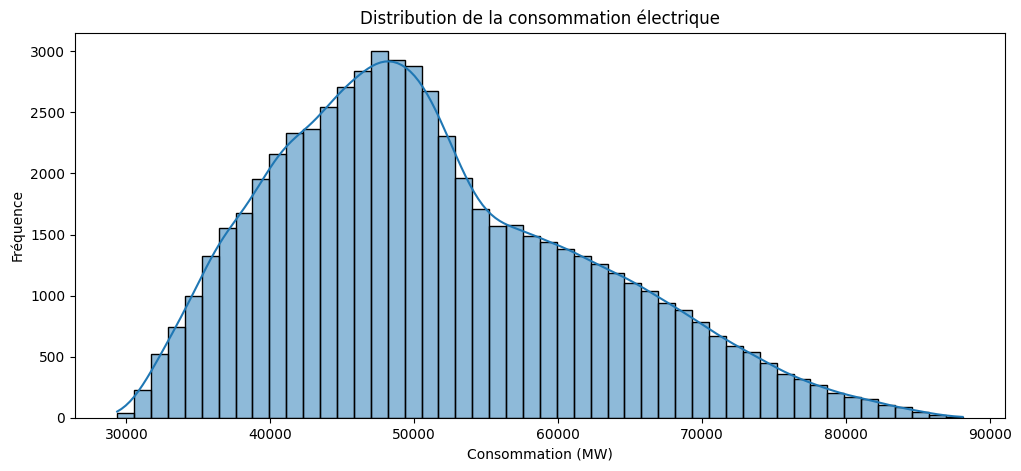

In [ ]:


plt.figure(figsize=(12, 5))

sns.histplot(
    df["consommation_mw"],
    bins=50,
    kde=True
)

plt.title(
    "Distribution de la consommation électrique"
)

plt.xlabel("Consommation (MW)")
plt.ylabel("Fréquence")

plt.show()

Boxplot des consommations

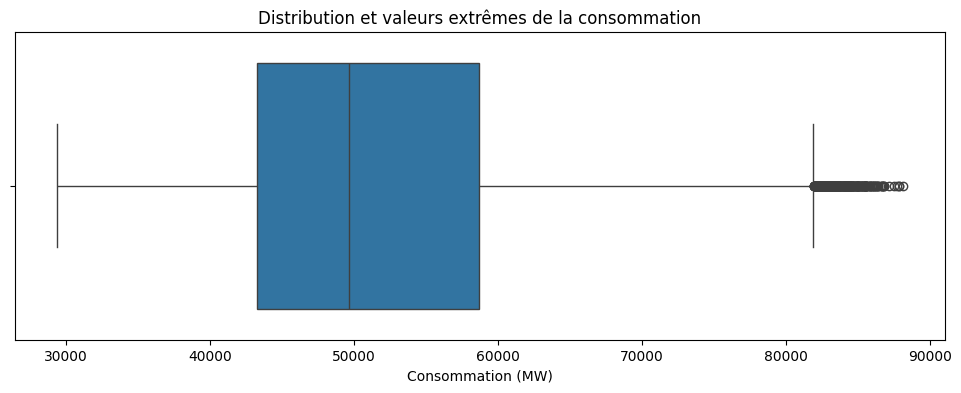

In [ ]:


plt.figure(figsize=(12, 4))

sns.boxplot(
    x=df["consommation_mw"]
)

plt.title(
    "Distribution et valeurs extrêmes de la consommation"
)

plt.xlabel("Consommation (MW)")

plt.show()

In [ ]:
# Vérification finale du dataframe après l'exploration

print("Dimensions du dataframe :", df.shape)

print("\nColonnes disponibles :")
print(df.columns.tolist())

print("\nAperçu des dernières lignes :")
display(df.tail())

print("\nValeurs manquantes :")
print(df.isna().sum())

print("\nPériode couverte :")
print("Début :", df["date_heure"].min())
print("Fin   :", df["date_heure"].max())

print("\nSaisons présentes :")
print(df["saison"].value_counts())

Dimensions du dataframe : (61368, 9)

Colonnes disponibles :
['date_heure', 'consommation_mw', 'heure', 'jour_semaine', 'mois', 'date', 'annee', 'corona', 'saison']

Aperçu des dernières lignes :


,date_heure,consommation_mw,heure,jour_semaine,mois,date,annee,corona,saison
61363,2025-12-31 19:00:00+00:00,72013.5,19,2,12,2025-12-31,2025,No,Hiver
61364,2025-12-31 20:00:00+00:00,69214.5,20,2,12,2025-12-31,2025,No,Hiver
61365,2025-12-31 21:00:00+00:00,68354.0,21,2,12,2025-12-31,2025,No,Hiver
61366,2025-12-31 22:00:00+00:00,70486.0,22,2,12,2025-12-31,2025,No,Hiver
61367,2025-12-31 23:00:00+00:00,70877.0,23,2,12,2025-12-31,2025,No,Hiver



Valeurs manquantes :
date_heure         0
consommation_mw    7
heure              0
jour_semaine       0
mois               0
date               0
annee              0
corona             0
saison             0
dtype: int64

Période couverte :
Début : 2019-01-01 00:00:00+00:00
Fin   : 2025-12-31 23:00:00+00:00

Saisons présentes :
saison
Printemps    15456
Été          15456
Automne      15288
Hiver        15168
Name: count, dtype: int64
